## **Smart Charging Network Planning: A Data-Driven Strategy for EV Development in Washington State**

Group - 3

Team Members: Fangzhou Zheng, Haojiang Wu, Yixi Yu, Pranaya Bindu Buyya

###**Introduction**

### **Problem Statement**
The increasing penetration of electric vehicles (EVs) presents significant challenges in charging infrastructure planning, geographic disparities in adoption, and policy effectiveness. Despite a 35% growth in EV sales (IEA, 2023), inadequate charging infrastructure remains a key barrier to widespread adoption (McKinsey, 2022). Moreover, most of studies do not consider EV distribution, location accessibility, and policy incentives together. Which leads to inefficient resource use and ineffective policies.

This study aims to analyze EV distribution, identify high-demand charging areas, and evaluate policy impact. The findings will:

* help policymakers assess the effectiveness of incentives like the Clean Alternative Fuel Vehicle (CAFV) program and make better infrastructure decisions.
* help energy providers optimize charging station locations to improve usage efficiency.
* help automakers understand regional demand patterns to refine marketing strategies.

By applying unsupervised machine learning methods, such as clustering and association rule mining, this study will uncover key trends in EV adoption. The results will offer data-driven insights to assist local government in optimizing EV deployment and infrastructure planning in Washington State to better serve local citizens.

### **Data Source**

**Source:** The dataset is made available for public release by the Washington Open Data Portal, providing up-to-date records of registered electric vehicles within the state.

**Dataset URL:** https://drive.google.com/file/d/1iLFacW1f3ENf4u6t4VgsW6GaeNn99za_/view?usp=drive_link   

**Data Dictionary:**

This dataset provides a comprehensive list of electric vehicles (EVs) registered in Washington State, including vehicle details, geographic location, and policy data. The data is taken from the Washington State Department of Licensing (DOL) and updated from time to time to reflect the latest EV registrations.

Dataset Size: approximately 51.7 MB

Number of Records: 22,392 rows (one for each EV registration)

Number of Attributes: 17 columns



| **Feature Name**               | **Description**                                           | **Data Type**                |
|--------------------------------|-----------------------------------------------------------|------------------------------|
| **VIN (1-10)**                 | First 10 digits of the Vehicle Identification Number      | Categorical                  |
| **County**                     | County where the EV is registered                        | Categorical                  |
| **City**                       | City of EV registration                                  | Categorical                  |
| **State**                      | State abbreviation                                       | Categorical                  |
| **Postal Code**                | ZIP code where the vehicle is registered                 | Categorical (Numeric)        |
| **Model Year**                 | Year the vehicle was manufactured                        | Numeric                      |
| **Make**                       | Vehicle manufacturer                                     | Categorical                  |
| **Model**                      | Specific model of the EV                                 | Categorical                  |
| **Electric Vehicle Type**       | EV classification (Battery or Hybrid)                   | Categorical                  |
| **CAFV Eligibility**           | Eligibility for Clean Alternative Fuel Vehicle incentives | Categorical                  |
| **Electric Range**             | Estimated driving range on a full charge (in miles)     | Numeric                      |
| **Base MSRP**                  | Manufacturer’s Suggested Retail Price                   | Numeric                      |
| **Legislative District**       | Washington legislative district                          | Categorical (Numeric)        |
|**DOL Vehicle ID**  |Unique number assigned to each vehicle by Department of Licensing for identification purposes| Numeric|
| **Vehicle Location**           | Geographic coordinates (latitude & longitude)           | Categorical (Converted to Numeric) |
| **Electric Utility**           | Power provider supplying electricity to the EV owner    | Categorical                  |
| **2020 Census Tract**         | Census demographic data reference                       | Categorical (Numeric)        |


## **Step 1: Data Cleaning & Preprocessing**

In [ ]:
#import data
import pandas as pd
import numpy as np

url = 'https://drive.google.com/uc?export=download&id=1iLFacW1f3ENf4u6t4VgsW6GaeNn99za_'
df = pd.read_csv(url)
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1C4JJXP66P,Kitsap,Poulsbo,WA,98370.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,23.0,258127145,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
1,1G1FX6S08K,Snohomish,Lake Stevens,WA,98258.0,2019,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,0.0,44.0,4735426,POINT (-122.06402 48.01497),PUGET SOUND ENERGY INC,5.306105e+10
2,WBY1Z2C58F,King,Seattle,WA,98116.0,2015,BMW,I3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,81.0,0.0,34.0,272697666,POINT (-122.41067 47.57894),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,5YJSA1V24F,Yakima,Selah,WA,98942.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,0.0,15.0,258112970,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223995 entries, 0 to 223994
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         223995 non-null  object 
 1   County                                             223992 non-null  object 
 2   City                                               223992 non-null  object 
 3   State                                              223995 non-null  object 
 4   Postal Code                                        223992 non-null  float64
 5   Model Year                                         223995 non-null  int64  
 6   Make                                               223995 non-null  object 
 7   Model                                              223995 non-null  object 
 8   Electric Vehicle Type                              223995 non-null  object

In [ ]:
df.isnull().sum()

,0
VIN (1-10),0
County,3
City,3
State,0
Postal Code,3
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().count()

,0
VIN (1-10),223496
County,223496
City,223496
State,223496
Postal Code,223496
Model Year,223496
Make,223496
Model,223496
Electric Vehicle Type,223496
Clean Alternative Fuel Vehicle (CAFV) Eligibility,223496


In [ ]:
df[['Longitude', 'Latitude']] = df['Vehicle Location'].str.extract(r'POINT \((-?\d+\.\d+) (-?\d+\.\d+)\)')
df['Longitude'] = df['Longitude'].astype(float)
df['Latitude'] = df['Latitude'].astype(float)
df.drop(columns=['Vehicle Location'], inplace=True)

df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Electric Utility,2020 Census Tract,Longitude,Latitude
0,1C4JJXP66P,Kitsap,Poulsbo,WA,98370.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,23.0,258127145,PUGET SOUND ENERGY INC,5.303509e+10,-122.64681,47.73689
1,1G1FX6S08K,Snohomish,Lake Stevens,WA,98258.0,2019,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,0.0,44.0,4735426,PUGET SOUND ENERGY INC,5.306105e+10,-122.06402,48.01497
2,WBY1Z2C58F,King,Seattle,WA,98116.0,2015,BMW,I3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,81.0,0.0,34.0,272697666,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10,-122.41067,47.57894
3,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10,-122.23825,47.49461
4,5YJSA1V24F,Yakima,Selah,WA,98942.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,0.0,15.0,258112970,PACIFICORP,5.307700e+10,-120.53145,46.65405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223990,7SAYGDEE4R,Pierce,Puyallup,WA,98374.0,2024,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,2.0,264662359,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10,-122.27575,47.13959
223991,WBY8P2C00M,Snohomish,Lake Stevens,WA,98258.0,2021,BMW,I3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,44.0,157728168,PUGET SOUND ENERGY INC,5.306105e+10,-122.06402,48.01497
223992,JN1AZ0CP3B,Pierce,University Place,WA,98466.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,0.0,28.0,261733433,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10,-122.53756,47.23165
223993,5YJ3E1EA2R,Pierce,Puyallup,WA,98374.0,2024,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,25.0,275283487,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10,-122.27575,47.13959


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223496 entries, 0 to 223994
Data columns (total 18 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         223496 non-null  object 
 1   County                                             223496 non-null  object 
 2   City                                               223496 non-null  object 
 3   State                                              223496 non-null  object 
 4   Postal Code                                        223496 non-null  float64
 5   Model Year                                         223496 non-null  int64  
 6   Make                                               223496 non-null  object 
 7   Model                                              223496 non-null  object 
 8   Electric Vehicle Type                              223496 non-null  object 
 9 

In [ ]:
df[df.select_dtypes(include=['object']).columns] = df.select_dtypes(include=['object']).apply(lambda x: x.astype('category'))

##**Step 2: Exploratory Data Analysis: Looking into Interesting Insights**

For this project, we are performing Electric Vehicle (EV) adoption in Washington State based on a dataset available.

The primary goal of this EDA is to gain insights into EV distribution, model popularity, infrastructure availability, and policy impact. Through statistical analysis and visualizations, we aim to answer the following primary questions:

In [ ]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract,Longitude,Latitude
count,223496.000000,223496.000000,223496.000000,223496.000000,223496.000000,2.234960e+05,2.234960e+05,223496.000000,223496.000000
mean,98269.193739,2021.265266,47.726599,828.337957,28.876356,2.329479e+08,5.304006e+10,-122.063454,47.458093
std,310.659079,2.989873,84.975652,7366.061719,14.911001,6.884834e+07,1.644383e+07,1.054376,0.619611
min,98001.000000,1999.000000,0.000000,0.000000,1.000000,4.385000e+03,5.300195e+10,-124.627350,45.579230
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.008299e+08,5.303301e+10,-122.401990,47.328000
50%,98126.000000,2022.000000,0.000000,0.000000,32.000000,2.488410e+08,5.303303e+10,-122.291790,47.603260
75%,98375.000000,2023.000000,39.000000,0.000000,42.000000,2.674022e+08,5.305307e+10,-122.131580,47.722380
max,99403.000000,2025.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.307794e+10,-117.043980,48.999760


### **a) What is the relative preference for Plug-in Hybrid Electric Vehicles (PHEVs) and Battery Electric Vehicles (BEVs)?**

Text(0.5, 0, 'Count')

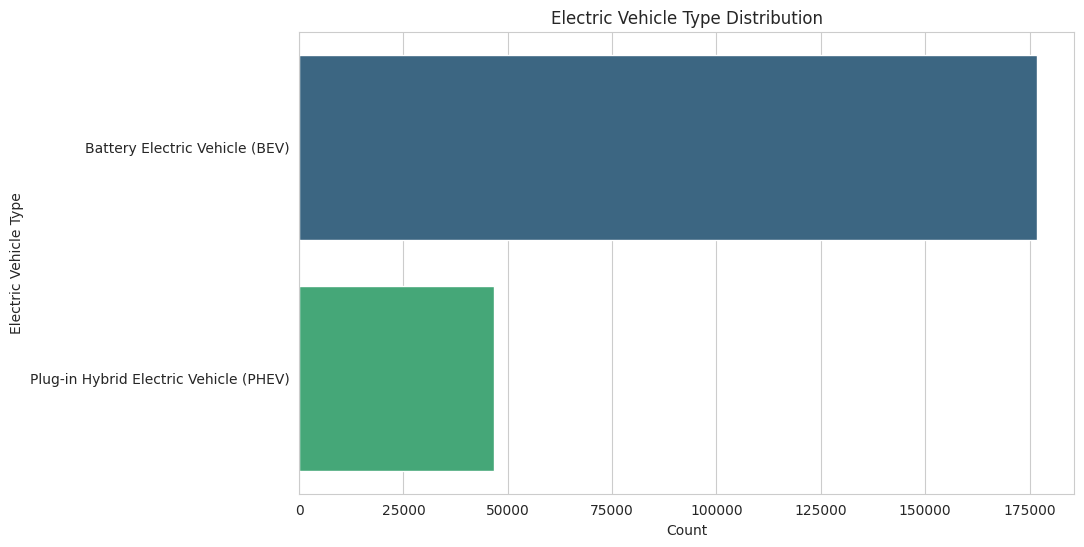

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.countplot(y='Electric Vehicle Type', data=df, palette='viridis', hue = 'Electric Vehicle Type')
plt.title('Electric Vehicle Type Distribution')
plt.xlabel('Count')

**Observations:**

Battery Electric Vehicles (BEVs) make up ~80% of the sample, and Plug-in Hybrid Electric Vehicles (PHEVs) make up a paltry ~20%. This indicates that there is high consumer demand for electric vehicles over hybrids, most likely due to improved charging infrastructure, longer battery lifespan, and government incentives favoring BEVs. While PHEVs have a niche market share, the trend is towards a continued move towards fully electric mobility as technology and infrastructure improve.

###**b) Which firms dominate the EV market?**

Text(0.5, 0, 'Count')

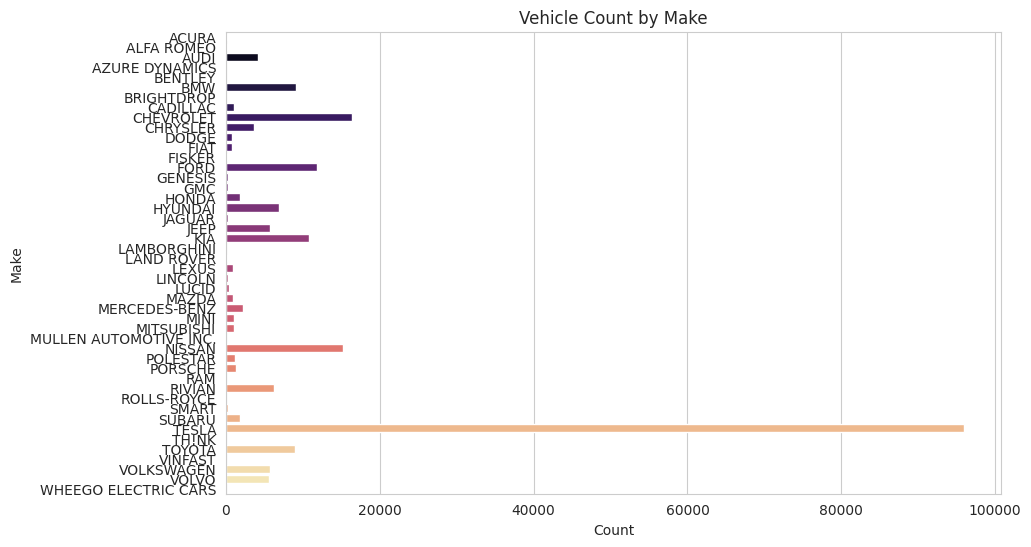

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.countplot(y='Make', data=df, palette='magma', hue = 'Make')
plt.title('Vehicle Count by Make')
plt.xlabel('Count')

**Observations:**

Tesla is the EV leader by a significant margin over the next largest firms, with Chevrolet and Nissan following closely behind as significant players in the affordable EV space. Firms like Ford, Toyota, and Hyundai exist but have a relatively small share of the market. Tesla's leadership might be a result of extensive charging stations, superior brand awareness, and superior battery technology, whereas Chevrolet and Nissan exist as evidence of sustained demand for affordable EVs.


###**c) How has the adoption of EV evolved over the years?**

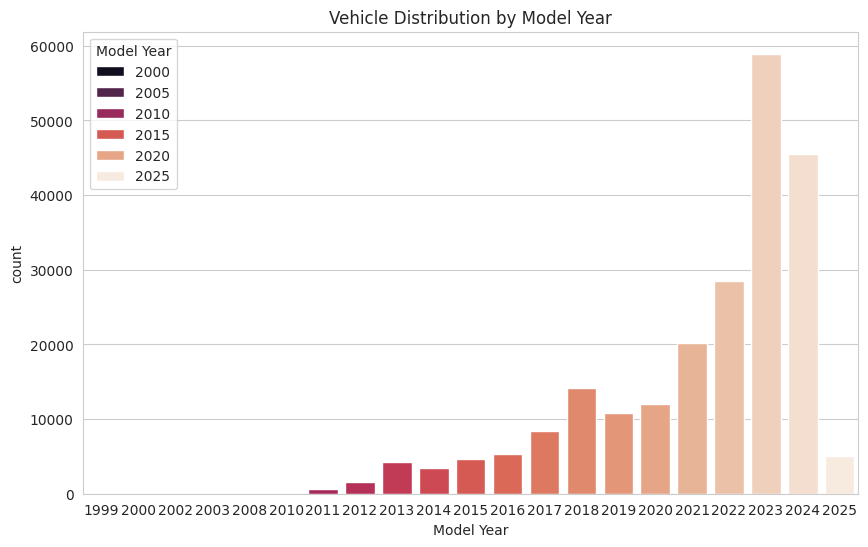

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.countplot(x='Model Year', data=df, palette='rocket', hue = 'Model Year')
plt.title('Vehicle Distribution by Model Year')
plt.show()

**Observations:**

The majority of the registered EVs are made after 2018, with 2022 and 2023 representing the peak. EVs made before 2010 are rare, indicating that early uptake was unpopular and started picking up pace only in the last decade. The sharp spike in registrations over recent years is a reflection of the increase in battery technology, decreased affordability, and heightened policy support that have been fueling the relatively faster growth of the EV market.

###**d) Where is EV adoption geographically concentrated?**

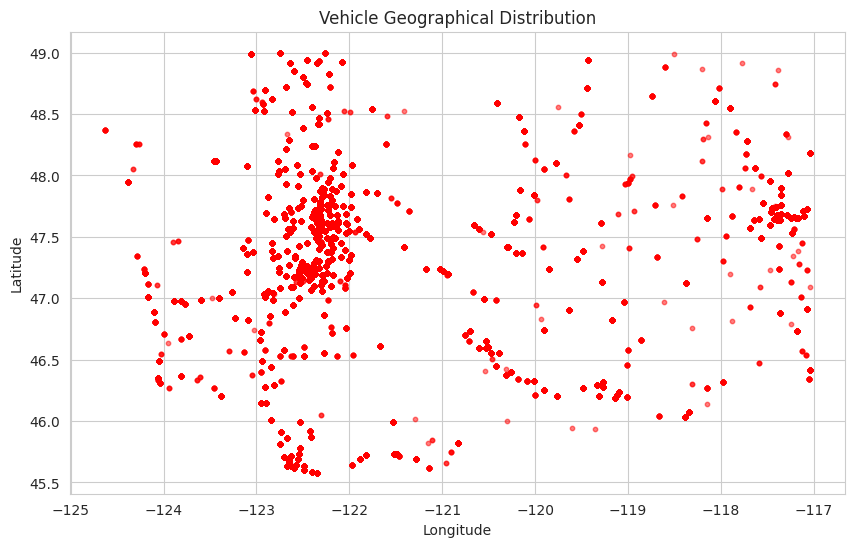

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["Longitude"], df["Latitude"], alpha=0.5, c='red', s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Vehicle Geographical Distribution")
plt.grid(True)
plt.show()

**Observations:**

EV adoption is most dense in urban centers, with Seattle, Bellevue, and Tacoma. Rural regions, particularly eastern Washington, are low in adoption, likely due to infrequent charging infrastructure and reduced EV incentives. The most dense EV adoption tracks along the I-5 corridor correspond to population density and infrastructure availability, and the outlying regions are underserved.

###**e) How EV Adoption Varies by County**

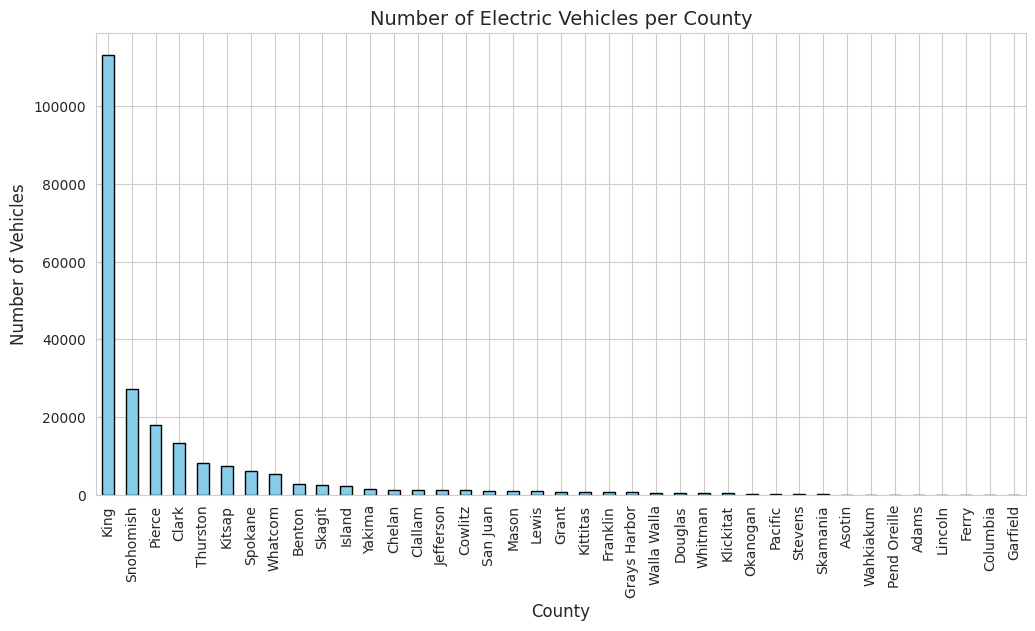

In [ ]:
county_vehicle_counts = df['County'].value_counts()

plt.figure(figsize=(12, 6))
county_vehicle_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Electric Vehicles per County', fontsize=14)
plt.xlabel('County', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.xticks(rotation=90)

plt.show()

**Observations:**

King County has the most electric vehicles by a huge margin, followed by Snohomish and Pierce. Most counties have a much smaller EV presence, which suggests that EV adoption is highly concentrated in a few key areas. It is possibly due to factors like charging infrastructure availability, population density, or government incentives.

###**f) How do government incentives like CAFV eligibility impact adoption?**

<ipython-input-150-f8b18fc486b8>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cafv_counts.index, y=cafv_counts.values, palette="coolwarm", order=cafv_counts.index)


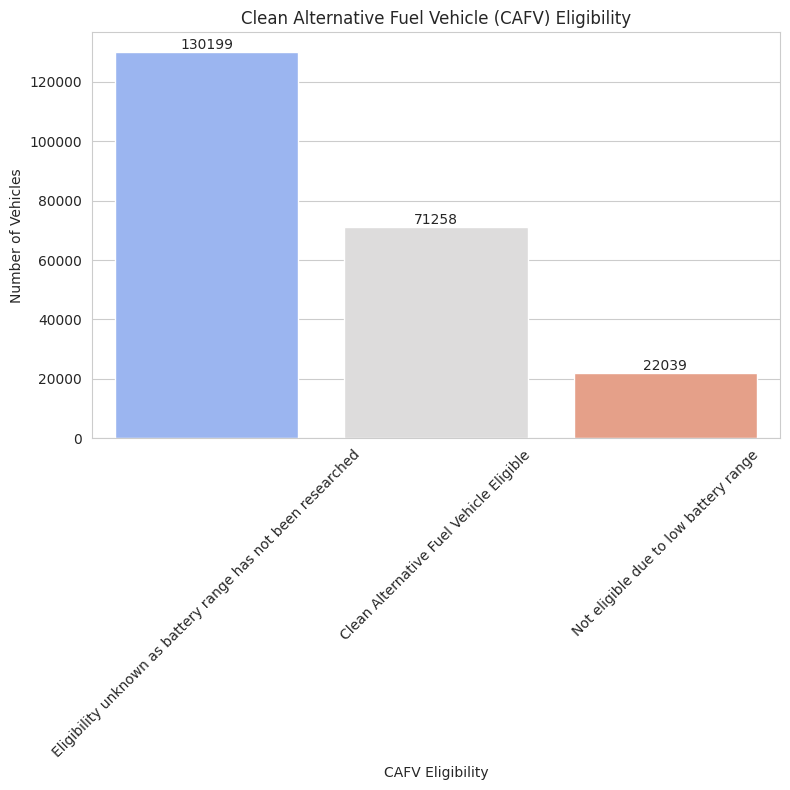

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cafv_counts = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")

sns.barplot(x=cafv_counts.index, y=cafv_counts.values, palette="coolwarm", order=cafv_counts.index)

plt.title('Clean Alternative Fuel Vehicle (CAFV) Eligibility')
plt.xlabel('CAFV Eligibility')
plt.ylabel('Number of Vehicles')

for i, count in enumerate(cafv_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations:**

Most EVs (130,199) are CAFV-eligible, with 71,258 excluded. This suggests government incentives as a significant factor in EV adoption since most vehicles qualify for state programs offering cash incentives. The high proportion of CAFV-eligible cars indicates the success of policy-driven adoption efforts, though the proportion excluded warns of possible limits in accessibility of incentives.

##**Step 3: Analysis of the distribution of CAFV eligibility ratios in different county clusters**

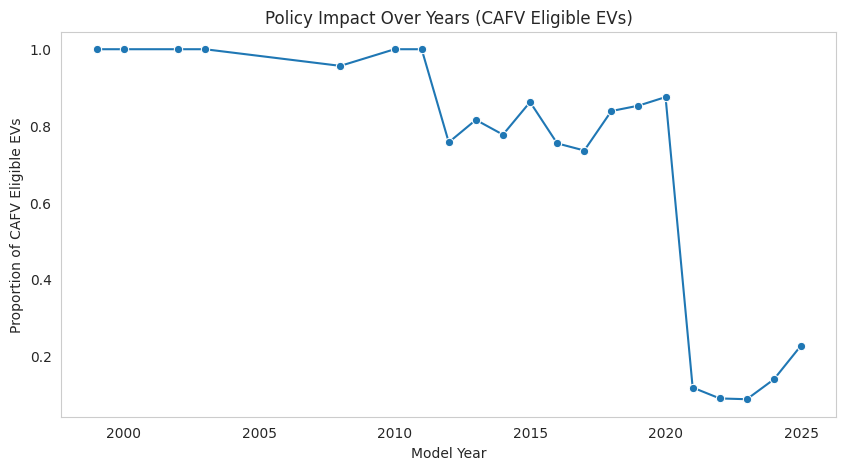

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

columns_to_use = ["Model Year", "County", "City",
                  "Clean Alternative Fuel Vehicle (CAFV) Eligibility", "Electric Vehicle Type"]
df_filtered = df[columns_to_use].dropna()
df_filtered["CAFV Eligible"] = df_filtered["Clean Alternative Fuel Vehicle (CAFV) Eligibility"].apply(lambda x: 1 if "Eligible" in x else 0)

yearly_policy_impact = df_filtered.groupby("Model Year")["CAFV Eligible"].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_policy_impact.index, y=yearly_policy_impact.values, marker="o")
plt.title("Policy Impact Over Years (CAFV Eligible EVs)")
plt.xlabel("Model Year")
plt.ylabel("Proportion of CAFV Eligible EVs")
plt.grid()
plt.show()

#### **PCA**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

county_pca_data = df_filtered.groupby("County").agg({"Model Year": "mean", "CAFV Eligible": "mean"}).dropna()


scaler = StandardScaler()
scaled_county_data = scaler.fit_transform(county_pca_data)

pca = PCA(n_components=2)
county_pca_result = pca.fit_transform(scaled_county_data)

<ipython-input-152-8c5d7381123a>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  county_pca_data = df_filtered.groupby("County").agg({"Model Year": "mean", "CAFV Eligible": "mean"}).dropna()


#### **Clusters selection based on Silhouette Score**

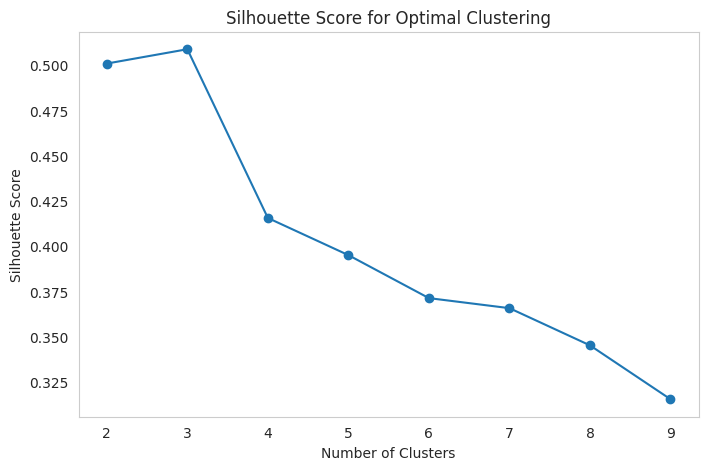

In [ ]:
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(county_pca_result)
    silhouette_avg = silhouette_score(county_pca_result, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Score for Optimal Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

#### K-Means Clustering

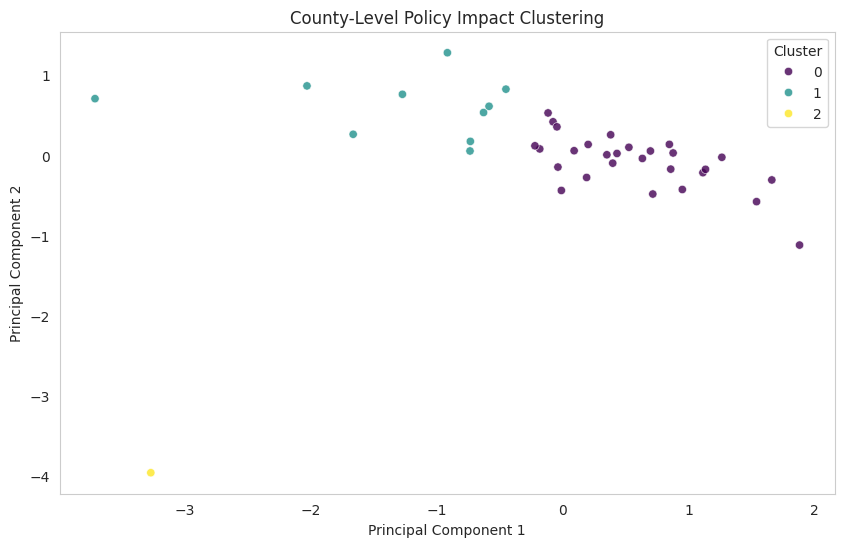

In [ ]:
optimal_clusters =3

kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
county_pca_data["PCA1"] = county_pca_result[:, 0]
county_pca_data["PCA2"] = county_pca_result[:, 1]
county_pca_data["Cluster"] = kmeans.fit_predict(county_pca_result)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=county_pca_data, x="PCA1", y="PCA2", hue="Cluster", palette="viridis", alpha=0.8)
plt.title("County-Level Policy Impact Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid()
plt.show()

#### **Output Analysis**

In [ ]:
print(county_pca_data)

               Model Year  CAFV Eligible      PCA1      PCA2  Cluster
County                                                               
Adams         2020.922078       0.311688  0.713993 -0.480456        0
Asotin        2021.111111       0.344444  0.524283  0.102171        0
Benton        2020.974412       0.383472 -0.077886  0.420202        0
Chelan        2021.116605       0.357196  0.379667  0.258207        0
Clallam       2020.482169       0.395988 -0.737024  0.056182        1
Clark         2021.171191       0.335242  0.695211  0.056122        0
Columbia      2021.176471       0.235294  1.879006 -1.116697        0
Cowlitz       2021.028621       0.345186  0.429804  0.025189        0
Douglas       2021.095723       0.334012  0.631278 -0.036809        0
Ferry         2020.764706       0.411765 -0.629383  0.535811        1
Franklin      2020.768666       0.342717  0.188748 -0.274088        0
Garfield      2017.333333       0.333333 -3.270906 -3.955000        2
Grant         2021.0

In [ ]:
cluster_summary = county_pca_data.groupby("Cluster").agg({"Model Year": "mean","CAFV Eligible": "mean"}).reset_index()
cluster_summary

,Cluster,Model Year,CAFV Eligible
0,0,2021.048037,0.334859
1,1,2020.490086,0.442216
2,2,2017.333333,0.333333


- **Cluster 0**: Most counties have relatively new electric vehicles (around 2021), but the proportion that meets the policy is average (30%-35%).
- **Cluster 1**: Electric vehicles are slightly older (around 2020), but the proportion that meets the policy is higher (40%-55%), and the policy support is strong.
- **Cluster 2**: Electric vehicles are the oldest (2017), the proportion that meets the policy is lower, the market development is slower, and the policy impact is smaller.

## **Step 4: Analysis of electric vehicle distribution and charging infrastructure in Washington State: Which areas need the most optimization?**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

####**PCA & K-Means**

In [ ]:
columns_to_use = ["Electric Vehicle Type", "City", "County", "Electric Utility",
                  "Latitude", "Longitude", "Model Year", "Legislative District"]
df_filtered = df[columns_to_use].dropna()

label_encoder = LabelEncoder()
df_filtered["Electric Vehicle Type"] = label_encoder.fit_transform(df_filtered["Electric Vehicle Type"])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_filtered[["Latitude", "Longitude", "Model Year"]])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
df_filtered["PCA1"] = pca_result[:, 0]
df_filtered["PCA2"] = pca_result[:, 1]

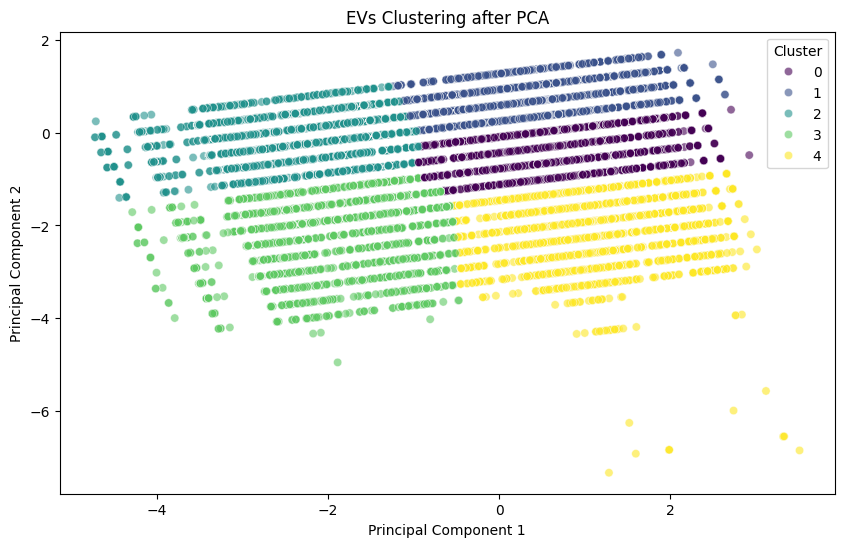

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_filtered["Cluster"] = kmeans.fit_predict(pca_result)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x="PCA1", y="PCA2", hue="Cluster", palette="viridis", alpha=0.6)
plt.title("EVs Clustering after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

####**Output Analysis**

In [ ]:
# View the distribution of BEV and PHEV in different Clusters
cluster_summary = df_filtered.groupby("Cluster")["Electric Vehicle Type"].value_counts().unstack()
print("BEV and PHEV count in each Cluster:")
print(cluster_summary)

BEV and PHEV count in each Cluster:
Electric Vehicle Type       0      1
Cluster                             
0                       39086  10391
1                      100550  19143
2                       17562   5127
3                        4686   3010
4                       14930   9011


In [ ]:
# Calculate the average Model Year for each Cluster
model_year_summary = df_filtered.groupby("Cluster")["Model Year"].mean()
print("\nAverage Model Year in each Cluster:")
print(model_year_summary)


Average Model Year in each Cluster:
Cluster
0    2019.667381
1    2023.196235
2    2022.687822
3    2016.510265
4    2015.093981
Name: Model Year, dtype: float64


In [ ]:
# Identify the top 5 cities in each Cluster
cluster_city_distribution = df_filtered.groupby("Cluster")["City"].value_counts().groupby(level=0).head(5)
print("\nTop 5 cities in each Cluster:")
print(cluster_city_distribution)


Top 5 cities in each Cluster:
Cluster  City      
0        Seattle       10295
         Bellevue       2653
         Redmond        1930
         Kirkland       1769
         Bothell        1642
1        Seattle       20588
         Bellevue       7280
         Redmond        5174
         Bothell        5081
         Renton         4500
2        Vancouver      6062
         Spokane        2805
         Camas          1552
         Ridgefield      963
         Richland        938
3        Vancouver      2041
         Spokane         905
         Camas           440
         Kennewick       352
         Richland        290
4        Seattle        4776
         Bellevue       1031
         Olympia         939
         Tacoma          788
         Bellingham      747
Name: count, dtype: int64


In [ ]:
# Identify the top 3 electric utilities in each Cluster
cluster_utility_distribution = df_filtered.groupby("Cluster")["Electric Utility"].value_counts().groupby(level=0).head(3)
print("\nTop 3 electric utilities in each Cluster:")
print(cluster_utility_distribution)


Top 3 electric utilities in each Cluster:
Cluster  Electric Utility                                                          
0        PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)                                 19482
         PUGET SOUND ENERGY INC                                                        11623
         CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)                                  10896
1        PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)                                 53705
         PUGET SOUND ENERGY INC                                                        28269
         CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)                                  22129
2        BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA)               9893
         BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||INLAND POWER & LIGHT COMPANY     2900
         PACIFICORP                                                                     1335
3        BONNEVILLE POWER ADMINISTRA

**Findings：**

1. Seattle and its surrounding areas (Clusters 1 and 0) are the most concentrated areas for EV vehicles, especially BEVs (pure electric vehicles), which indicates that the charging infrastructure in these areas is relatively complete and car owners are more inclined to buy all-electric vehicles.

2. The electric vehicle market in eastern areas such as Vancouver and Spokane (Clusters 2 and 3) is relatively small and more inclined to PHEVs (plug-in hybrid electric vehicles), which may be due to the lack of fast charging stations and car owners prefer hybrid vehicles.

3. The old EVs from 2015-2016 are mainly concentrated in Clusters 3 and 4, while most of the new cars from 2022-2023 are in Clusters 1 and 2, indicating that the EV market is more active in large cities, while the penetration rate of new cars in smaller cities and rural areas is lower.

4. In terms of power companies, Puget Sound Energy and City of Seattle need to provide stronger power support, while areas covered by companies such as Bonneville Power Administration have slower EV development and may need more policy support and charging station construction.